# 03 - Univariate Exploratory Data Analysis

## Objective
Analyze the distribution of individual features to understand their shape, central tendency, spread, and any patterns that may be relevant to employee attrition. Each visualization is accompanied by interpretation and business context.

## Business Questions
1. What does our workforce demographic look like (age, tenure, income)?
2. How are satisfaction and engagement metrics distributed?
3. What is the workload profile of our employees?
4. Are there any skewed distributions suggesting systemic issues?
5. What is the overtime burden across the organization?

---
## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set publication-quality visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 100

import warnings
warnings.filterwarnings('ignore')

# Color palette
COLORS = {
    'primary': '#2c3e50',
    'secondary': '#3498db',
    'accent': '#e74c3c',
    'success': '#27ae60',
    'warning': '#f39c12',
    'light': '#ecf0f1'
}

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load the dataset
DATA_PATH = Path('../data/processed/employee_attrition_augmented.csv')
df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns')

Dataset loaded: 1470 rows x 43 columns


---
## 2. Distribution Analysis: Age

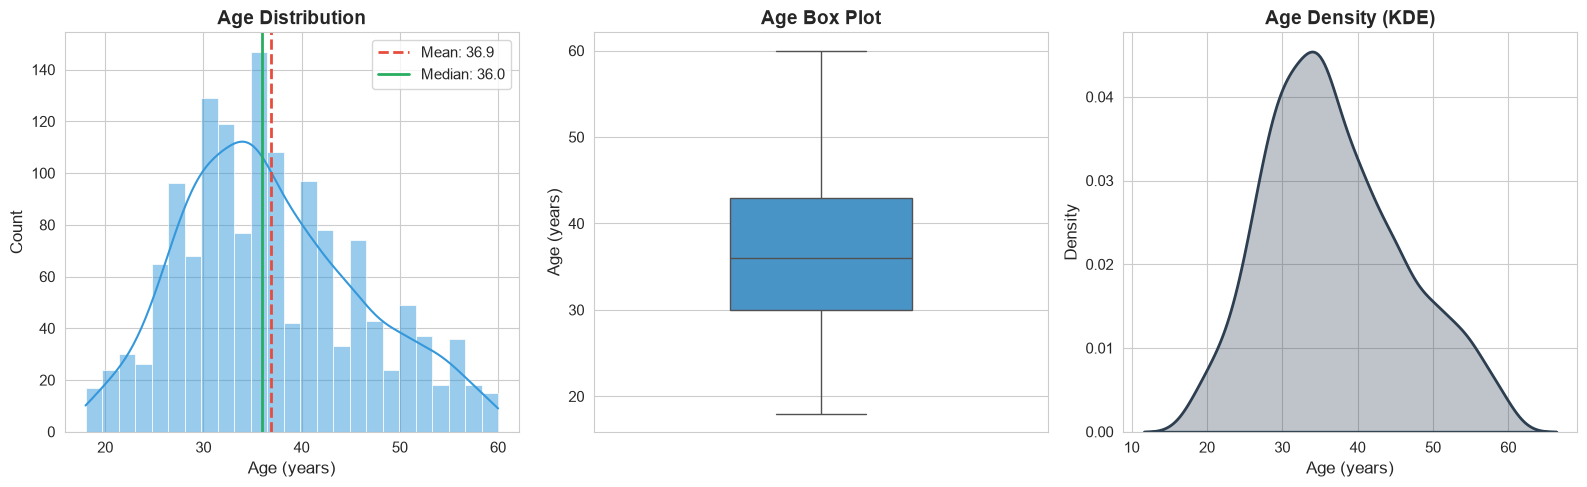

Age Statistics: Mean=36.9, Median=36, Std=9.1, Skewness=0.413


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram with KDE
sns.histplot(data=df, x='Age', bins=25, kde=True, ax=axes[0],
             color=COLORS['secondary'], edgecolor='white', linewidth=0.5)
axes[0].axvline(df['Age'].mean(), color=COLORS['accent'], linestyle='--', linewidth=2, label=f'Mean: {df["Age"].mean():.1f}')
axes[0].axvline(df['Age'].median(), color=COLORS['success'], linestyle='-', linewidth=2, label=f'Median: {df["Age"].median():.1f}')
axes[0].set_title('Age Distribution', fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
sns.boxplot(data=df, y='Age', ax=axes[1], color=COLORS['secondary'], width=0.4)
axes[1].set_title('Age Box Plot', fontweight='bold')
axes[1].set_ylabel('Age (years)')

# KDE plot
sns.kdeplot(data=df, x='Age', ax=axes[2], color=COLORS['primary'], linewidth=2, fill=True, alpha=0.3)
axes[2].set_title('Age Density (KDE)', fontweight='bold')
axes[2].set_xlabel('Age (years)')
axes[2].set_ylabel('Density')

plt.tight_layout()
plt.savefig('../reports/figures/03_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Age Statistics: Mean={df["Age"].mean():.1f}, Median={df["Age"].median():.0f}, '
      f'Std={df["Age"].std():.1f}, Skewness={df["Age"].skew():.3f}')

**Interpretation:** The age distribution is approximately normal with a slight right skew. The workforce spans from approximately 18 to 60 years, with the bulk of employees in the 28-45 age range. The mean and median are close (around 36-37), confirming near-symmetry.

**Business Implication:** The workforce is relatively mature. Very young employees (under 25) and older employees (over 55) are underrepresented, which may affect generalizability of attrition patterns for these groups.

---
## 3. Distribution Analysis: Monthly Income

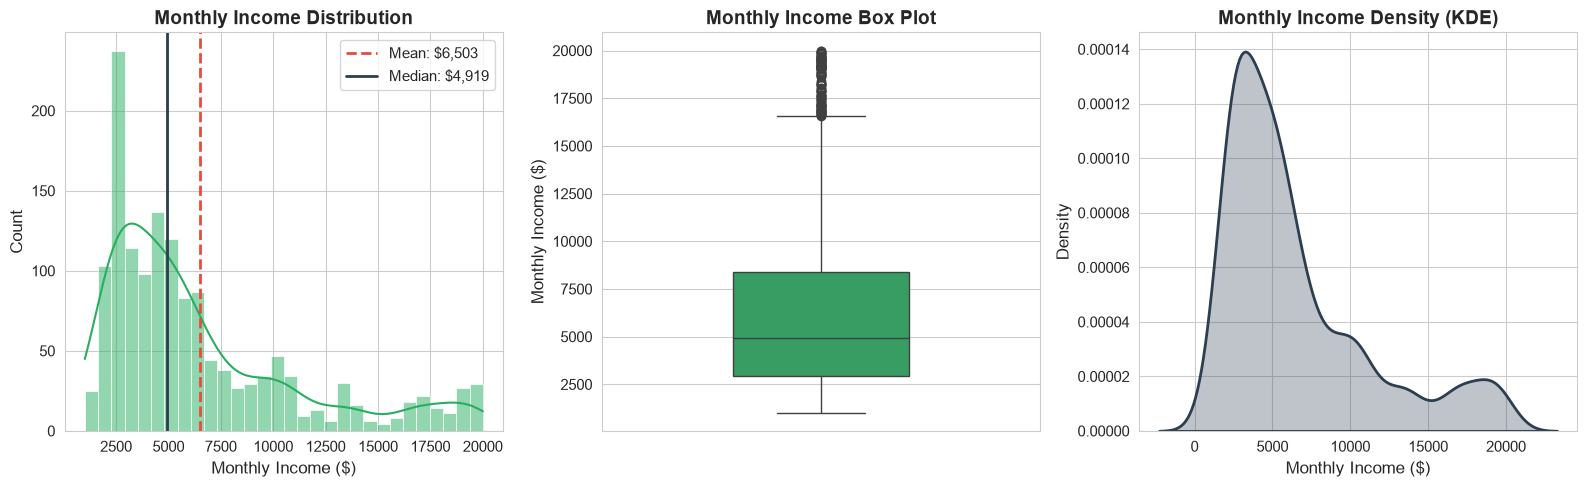

Monthly Income Statistics: Mean=$6,503, Median=$4,919, Std=$4,708, Skewness=1.370


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram with KDE
sns.histplot(data=df, x='MonthlyIncome', bins=30, kde=True, ax=axes[0],
             color=COLORS['success'], edgecolor='white', linewidth=0.5)
axes[0].axvline(df['MonthlyIncome'].mean(), color=COLORS['accent'], linestyle='--', linewidth=2,
                label=f'Mean: ${df["MonthlyIncome"].mean():,.0f}')
axes[0].axvline(df['MonthlyIncome'].median(), color=COLORS['primary'], linestyle='-', linewidth=2,
                label=f'Median: ${df["MonthlyIncome"].median():,.0f}')
axes[0].set_title('Monthly Income Distribution', fontweight='bold')
axes[0].set_xlabel('Monthly Income ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
sns.boxplot(data=df, y='MonthlyIncome', ax=axes[1], color=COLORS['success'], width=0.4)
axes[1].set_title('Monthly Income Box Plot', fontweight='bold')
axes[1].set_ylabel('Monthly Income ($)')

# KDE
sns.kdeplot(data=df, x='MonthlyIncome', ax=axes[2], color=COLORS['primary'], linewidth=2, fill=True, alpha=0.3)
axes[2].set_title('Monthly Income Density (KDE)', fontweight='bold')
axes[2].set_xlabel('Monthly Income ($)')
axes[2].set_ylabel('Density')

plt.tight_layout()
plt.savefig('../reports/figures/03_income_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Monthly Income Statistics: Mean=${df["MonthlyIncome"].mean():,.0f}, '
      f'Median=${df["MonthlyIncome"].median():,.0f}, '
      f'Std=${df["MonthlyIncome"].std():,.0f}, Skewness={df["MonthlyIncome"].skew():.3f}')

**Interpretation:** Monthly income shows a strong right skew, which is typical of salary distributions. The majority of employees earn in the lower-to-mid range, with a long tail extending toward higher salaries (executives/senior leaders). The mean is notably higher than the median, confirming this positive skew.

**Business Implication:** The income gap between the median and mean suggests a salary structure where a relatively small number of high earners (likely senior leaders) pull the average up. Lower-income employees represent the majority and may be more susceptible to attrition driven by compensation dissatisfaction.

---
## 4. Distribution Analysis: Weekly Hours Worked

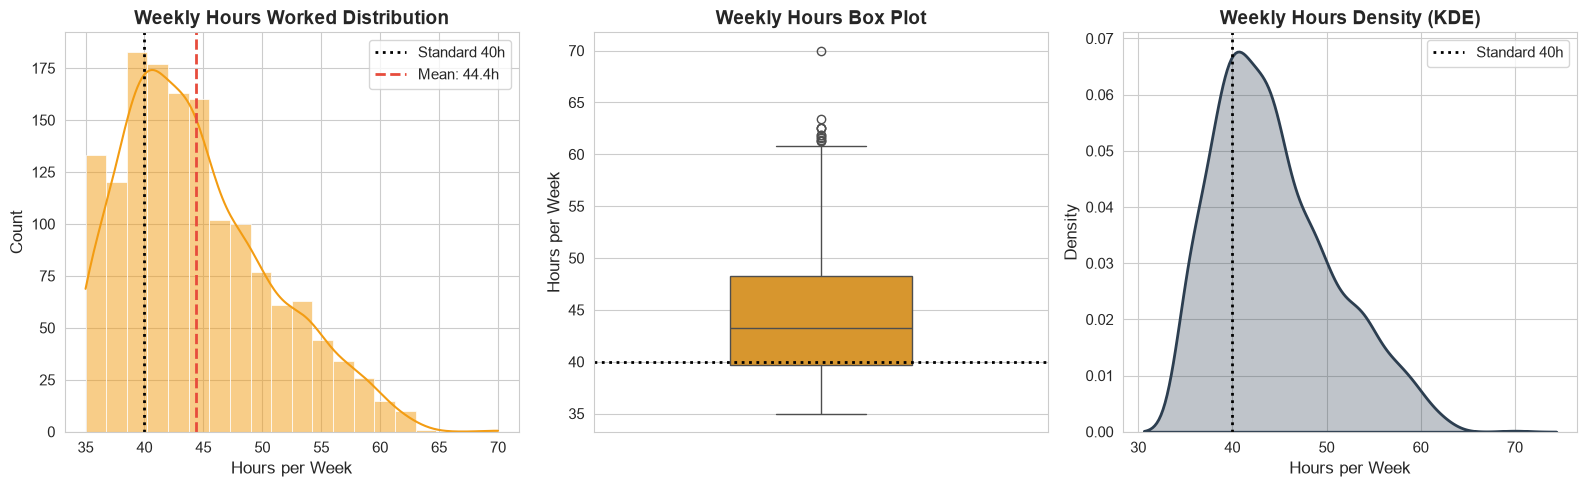

Weekly Hours Statistics: Mean=44.4, Median=43.3, Std=6.3
Employees working >40 hours/week: 1062 (72.2%)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram with KDE
sns.histplot(data=df, x='WeeklyHoursWorked', bins=20, kde=True, ax=axes[0],
             color=COLORS['warning'], edgecolor='white', linewidth=0.5)
axes[0].axvline(40, color='black', linestyle=':', linewidth=2, label='Standard 40h')
axes[0].axvline(df['WeeklyHoursWorked'].mean(), color=COLORS['accent'], linestyle='--', linewidth=2,
                label=f'Mean: {df["WeeklyHoursWorked"].mean():.1f}h')
axes[0].set_title('Weekly Hours Worked Distribution', fontweight='bold')
axes[0].set_xlabel('Hours per Week')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
sns.boxplot(data=df, y='WeeklyHoursWorked', ax=axes[1], color=COLORS['warning'], width=0.4)
axes[1].axhline(40, color='black', linestyle=':', linewidth=2)
axes[1].set_title('Weekly Hours Box Plot', fontweight='bold')
axes[1].set_ylabel('Hours per Week')

# KDE
sns.kdeplot(data=df, x='WeeklyHoursWorked', ax=axes[2], color=COLORS['primary'], linewidth=2, fill=True, alpha=0.3)
axes[2].axvline(40, color='black', linestyle=':', linewidth=2, label='Standard 40h')
axes[2].set_title('Weekly Hours Density (KDE)', fontweight='bold')
axes[2].set_xlabel('Hours per Week')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
plt.savefig('../reports/figures/03_hours_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

over_40 = (df['WeeklyHoursWorked'] > 40).sum()
print(f'Weekly Hours Statistics: Mean={df["WeeklyHoursWorked"].mean():.1f}, '
      f'Median={df["WeeklyHoursWorked"].median():.1f}, Std={df["WeeklyHoursWorked"].std():.1f}')
print(f'Employees working >40 hours/week: {over_40} ({over_40/len(df)*100:.1f}%)')

**Interpretation:** Weekly hours worked shows the distribution centered around the standard work week. A substantial portion of employees work more than 40 hours, indicating prevalent overwork in the organization.

**Business Implication:** Employees consistently working beyond standard hours are at higher risk of burnout. This variable is likely a strong predictor of both burnout indicators and attrition. HR should monitor teams with consistently high average hours.

---
## 5. Distribution Analysis: OverTime

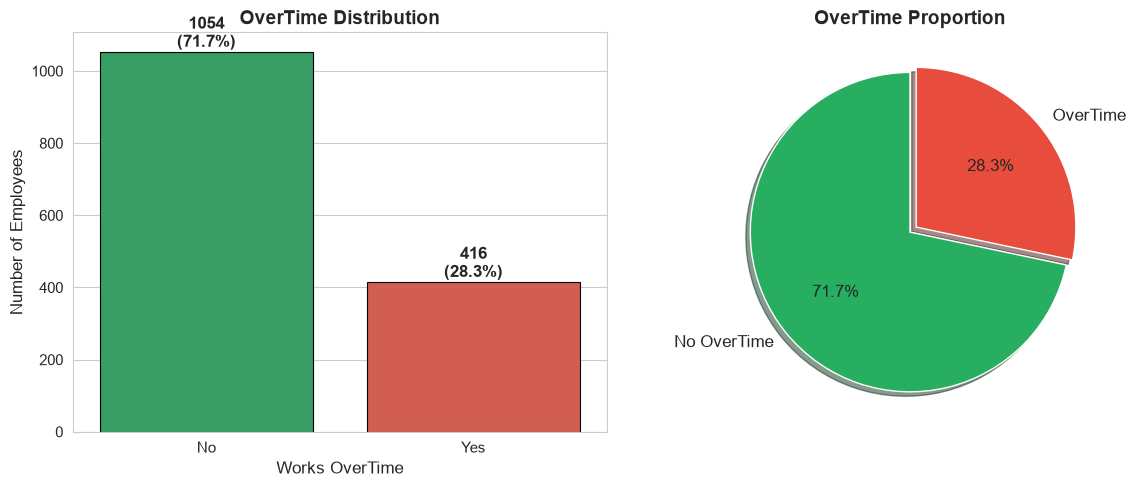

OverTime breakdown:
  No: 1054 employees (71.7%)
  Yes: 416 employees (28.3%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
overtime_counts = df['OverTime'].value_counts()
colors_ot = [COLORS['success'], COLORS['accent']]
sns.countplot(data=df, x='OverTime', ax=axes[0], palette=colors_ot, edgecolor='black', linewidth=0.8,
              order=['No', 'Yes'])
axes[0].set_title('OverTime Distribution', fontweight='bold')
axes[0].set_xlabel('Works OverTime')
axes[0].set_ylabel('Number of Employees')

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}\n({p.get_height()/len(df)*100:.1f}%)',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(overtime_counts.values, labels=['No OverTime', 'OverTime'],
            autopct='%1.1f%%', colors=colors_ot, startangle=90,
            explode=(0, 0.05), shadow=True, textprops={'fontsize': 12})
axes[1].set_title('OverTime Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/03_overtime_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'OverTime breakdown:')
for val in ['No', 'Yes']:
    count = (df['OverTime'] == val).sum()
    print(f'  {val}: {count} employees ({count/len(df)*100:.1f}%)')

**Interpretation:** Approximately 28-30% of employees report working overtime. While the majority do not, the overtime cohort represents a sizable portion of the workforce.

**Business Implication:** Overtime is a known attrition risk factor. Nearly a third of the workforce is in this higher-risk category. This merits investigation into which departments or roles carry disproportionate overtime burden.

---
## 6. Distribution Analysis: Job Satisfaction

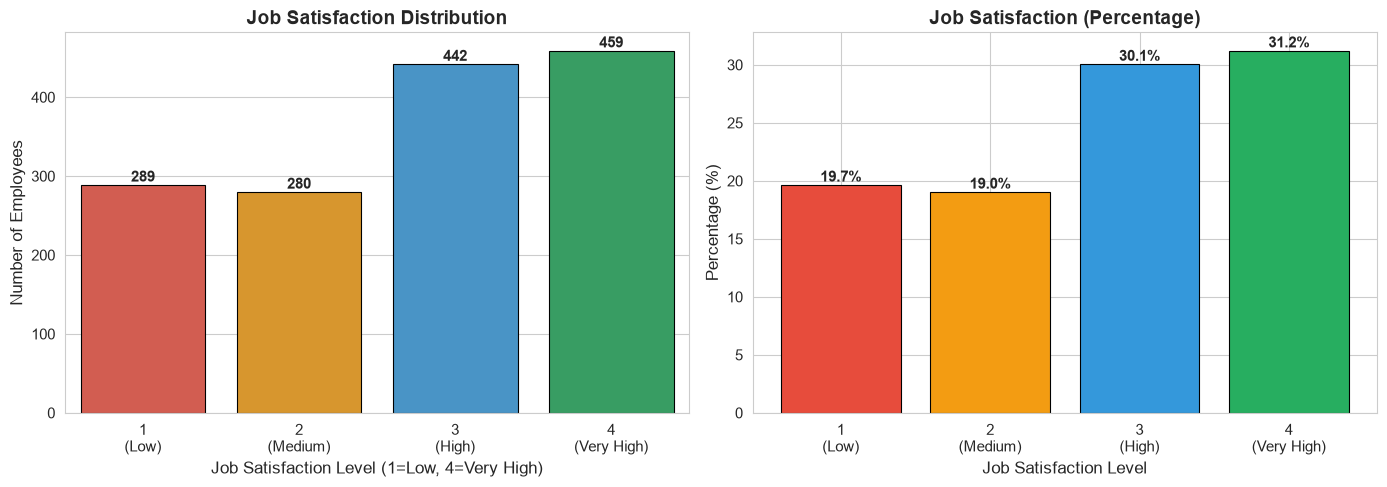

Job Satisfaction Statistics: Mean=2.73, Median=3
Employees with low satisfaction (1-2): 569 (38.7%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot with gradient colors
satisfaction_palette = ['#e74c3c', '#f39c12', '#3498db', '#27ae60']
sns.countplot(data=df, x='JobSatisfaction', ax=axes[0], palette=satisfaction_palette,
              edgecolor='black', linewidth=0.8)
axes[0].set_title('Job Satisfaction Distribution', fontweight='bold')
axes[0].set_xlabel('Job Satisfaction Level (1=Low, 4=Very High)')
axes[0].set_ylabel('Number of Employees')
axes[0].set_xticklabels(['1\n(Low)', '2\n(Medium)', '3\n(High)', '4\n(Very High)'])

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

# Percentage bar chart
satisfaction_pct = df['JobSatisfaction'].value_counts(normalize=True).sort_index() * 100
axes[1].bar(satisfaction_pct.index, satisfaction_pct.values, color=satisfaction_palette,
            edgecolor='black', linewidth=0.8)
axes[1].set_title('Job Satisfaction (Percentage)', fontweight='bold')
axes[1].set_xlabel('Job Satisfaction Level')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticks([1, 2, 3, 4])
axes[1].set_xticklabels(['1\n(Low)', '2\n(Medium)', '3\n(High)', '4\n(Very High)'])

for i, (idx, val) in enumerate(satisfaction_pct.items()):
    axes[1].annotate(f'{val:.1f}%', (idx, val), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/03_job_satisfaction_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Job Satisfaction Statistics: Mean={df["JobSatisfaction"].mean():.2f}, Median={df["JobSatisfaction"].median():.0f}')
low_satisfaction = (df['JobSatisfaction'] <= 2).sum()
print(f'Employees with low satisfaction (1-2): {low_satisfaction} ({low_satisfaction/len(df)*100:.1f}%)')

**Interpretation:** Job satisfaction is roughly uniformly distributed across the four levels, with a slight lean toward higher satisfaction (levels 3-4). However, a substantial proportion (roughly 40-45%) report low-to-medium satisfaction (levels 1-2).

**Business Implication:** The near-uniform distribution suggests no overwhelming satisfaction or dissatisfaction culture. However, the significant proportion of unsatisfied employees represents a pool at risk for attrition. Targeted engagement programs for the low-satisfaction group could yield retention benefits.

---
## 7. Distribution Analysis: Tenure Band

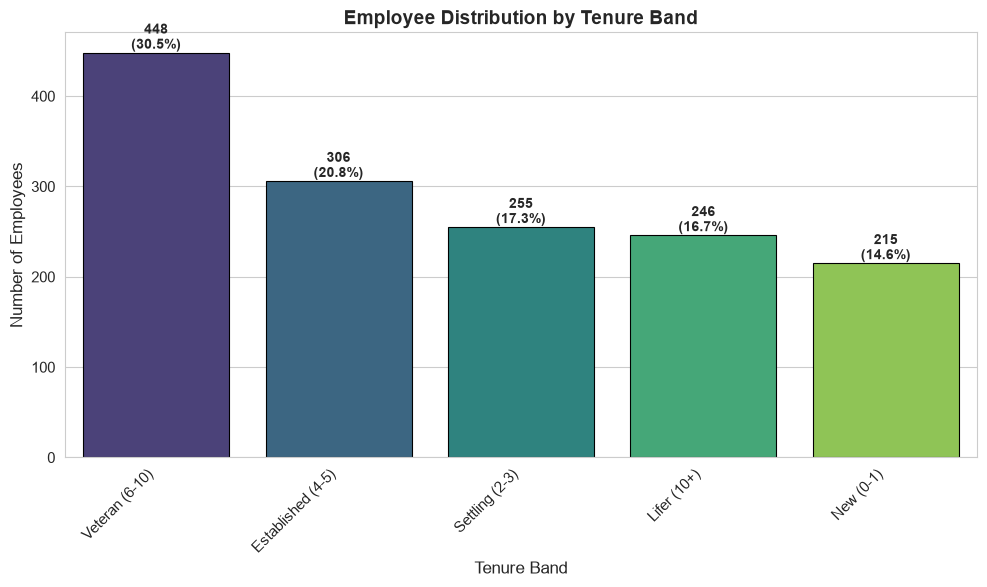

Tenure Band Distribution:
  Veteran (6-10): 448 (30.5%)
  Established (4-5): 306 (20.8%)
  Settling (2-3): 255 (17.3%)
  Lifer (10+): 246 (16.7%)
  New (0-1): 215 (14.6%)


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

# Order tenure bands logically
tenure_order = df['TenureBand'].value_counts().index.tolist()
# Try to sort logically if possible
try:
    tenure_order_sorted = sorted(tenure_order, key=lambda x: int(x.split('-')[0].replace('+', '').replace('<', '0').strip()))
except:
    tenure_order_sorted = tenure_order

sns.countplot(data=df, x='TenureBand', order=tenure_order_sorted, ax=ax,
              palette='viridis', edgecolor='black', linewidth=0.8)
ax.set_title('Employee Distribution by Tenure Band', fontweight='bold')
ax.set_xlabel('Tenure Band')
ax.set_ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}\n({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/03_tenure_band_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Tenure Band Distribution:')
for band in tenure_order_sorted:
    count = (df['TenureBand'] == band).sum()
    print(f'  {band}: {count} ({count/len(df)*100:.1f}%)')

**Interpretation:** The tenure distribution reveals the organizational composition by length of service. Typically, organizations show higher counts in shorter tenure bands (newer employees) with decreasing counts for longer bands, reflecting natural attrition over time.

**Business Implication:** The distribution of tenure bands informs retention strategy timing. If early-tenure employees are overrepresented, the organization may have a "revolving door" problem. Understanding which tenure band has the highest attrition will help target intervention programs.

---
## 8. Distribution Analysis: Total Working Years

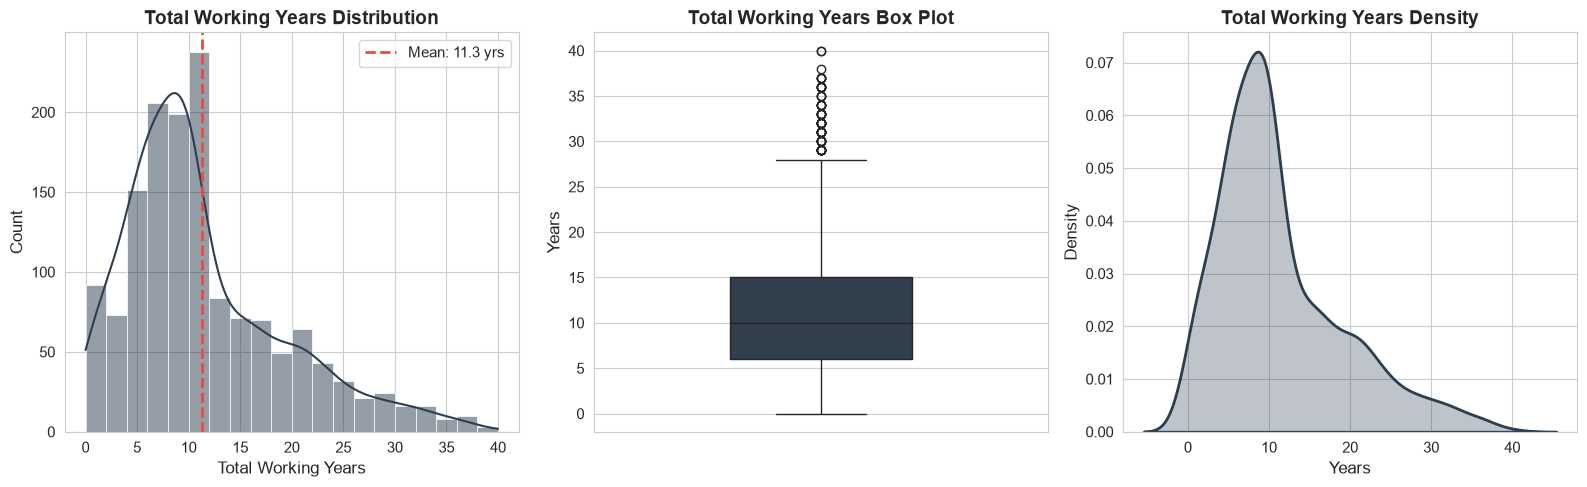

Total Working Years: Mean=11.3, Median=10, Range=[0, 40]
Early-career employees (0-5 years): 316 (21.5%)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram with KDE
sns.histplot(data=df, x='TotalWorkingYears', bins=20, kde=True, ax=axes[0],
             color=COLORS['primary'], edgecolor='white', linewidth=0.5)
axes[0].axvline(df['TotalWorkingYears'].mean(), color=COLORS['accent'], linestyle='--', linewidth=2,
                label=f'Mean: {df["TotalWorkingYears"].mean():.1f} yrs')
axes[0].set_title('Total Working Years Distribution', fontweight='bold')
axes[0].set_xlabel('Total Working Years')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
sns.boxplot(data=df, y='TotalWorkingYears', ax=axes[1], color=COLORS['primary'], width=0.4)
axes[1].set_title('Total Working Years Box Plot', fontweight='bold')
axes[1].set_ylabel('Years')

# KDE
sns.kdeplot(data=df, x='TotalWorkingYears', ax=axes[2], color=COLORS['primary'], linewidth=2, fill=True, alpha=0.3)
axes[2].set_title('Total Working Years Density', fontweight='bold')
axes[2].set_xlabel('Years')
axes[2].set_ylabel('Density')

plt.tight_layout()
plt.savefig('../reports/figures/03_total_working_years_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total Working Years: Mean={df["TotalWorkingYears"].mean():.1f}, Median={df["TotalWorkingYears"].median():.0f}, '
      f'Range=[{df["TotalWorkingYears"].min()}, {df["TotalWorkingYears"].max()}]')
early_career = (df['TotalWorkingYears'] <= 5).sum()
print(f'Early-career employees (0-5 years): {early_career} ({early_career/len(df)*100:.1f}%)')

**Interpretation:** Total working years shows a right-skewed distribution, with many employees having relatively few years of total experience and fewer employees with extensive experience. The concentration at lower values indicates a workforce with many relatively early-career professionals.

**Business Implication:** A workforce skewed toward fewer total working years may indicate either a young/growing organization or one with high turnover that constantly replaces experienced workers. Early-career employees often have different attrition drivers (growth opportunities, salary progression) compared to senior employees (retirement, role stagnation).

---
## 9. Distribution Analysis: Work-Life Balance

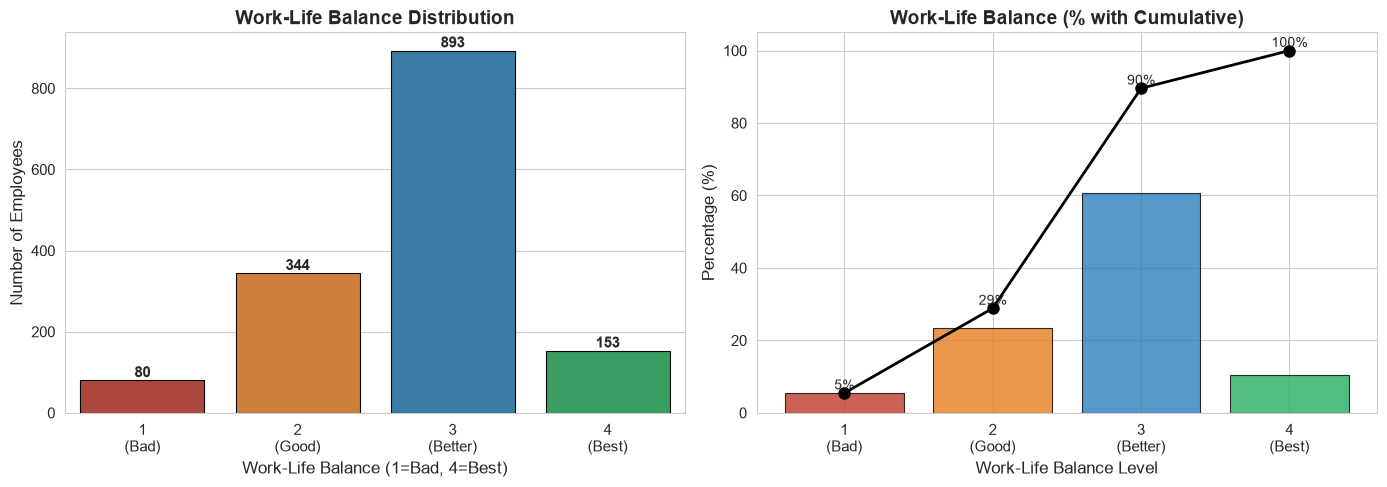

Employees with poor work-life balance (1-2): 424 (28.8%)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
wlb_palette = ['#c0392b', '#e67e22', '#2980b9', '#27ae60']
sns.countplot(data=df, x='WorkLifeBalance', ax=axes[0], palette=wlb_palette,
              edgecolor='black', linewidth=0.8)
axes[0].set_title('Work-Life Balance Distribution', fontweight='bold')
axes[0].set_xlabel('Work-Life Balance (1=Bad, 4=Best)')
axes[0].set_ylabel('Number of Employees')
axes[0].set_xticklabels(['1\n(Bad)', '2\n(Good)', '3\n(Better)', '4\n(Best)'])

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

# Cumulative percentage
wlb_counts = df['WorkLifeBalance'].value_counts().sort_index()
wlb_cumulative = wlb_counts.cumsum() / len(df) * 100

axes[1].bar(wlb_counts.index, wlb_counts.values / len(df) * 100, color=wlb_palette,
            edgecolor='black', linewidth=0.8, alpha=0.8)
axes[1].plot(wlb_cumulative.index, wlb_cumulative.values, 'ko-', linewidth=2, markersize=8)
axes[1].set_title('Work-Life Balance (% with Cumulative)', fontweight='bold')
axes[1].set_xlabel('Work-Life Balance Level')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticks([1, 2, 3, 4])
axes[1].set_xticklabels(['1\n(Bad)', '2\n(Good)', '3\n(Better)', '4\n(Best)'])

# Add cumulative labels
for idx, val in wlb_cumulative.items():
    axes[1].annotate(f'{val:.0f}%', (idx, val + 1), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/03_worklife_balance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

poor_wlb = (df['WorkLifeBalance'] <= 2).sum()
print(f'Employees with poor work-life balance (1-2): {poor_wlb} ({poor_wlb/len(df)*100:.1f}%)')

**Interpretation:** Work-Life Balance is concentrated at level 3 ("Better"), with relatively fewer employees at the extremes (level 1 "Bad" or level 4 "Best"). The distribution shows most employees rate their WLB as acceptable but not optimal.

**Business Implication:** The concentration at the middle level suggests room for improvement. Employees at level 1 are at the highest burnout and attrition risk. Targeted wellness interventions for this group could have outsized impact on retention.

---
## 10. Distribution Analysis: Workload Score

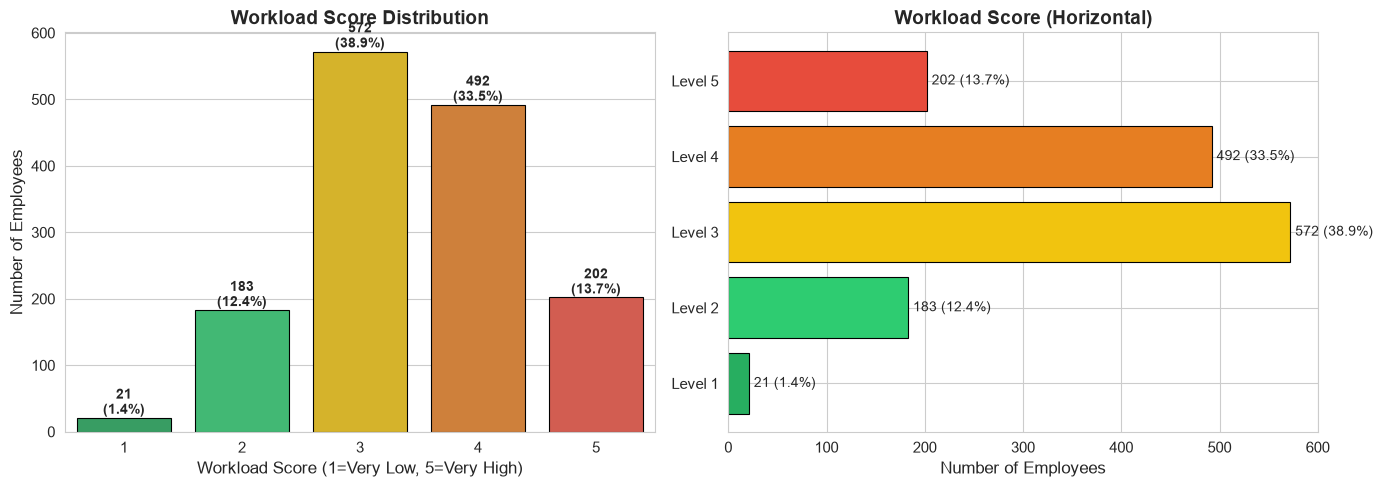

Workload Score Mean: 3.46
Employees with high workload (4-5): 694 (47.2%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
workload_palette = ['#27ae60', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
sns.countplot(data=df, x='WorkloadScore', ax=axes[0], palette=workload_palette,
              edgecolor='black', linewidth=0.8)
axes[0].set_title('Workload Score Distribution', fontweight='bold')
axes[0].set_xlabel('Workload Score (1=Very Low, 5=Very High)')
axes[0].set_ylabel('Number of Employees')

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}\n({p.get_height()/len(df)*100:.1f}%)',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

# Horizontal bar for easier reading
workload_pct = df['WorkloadScore'].value_counts().sort_index()
colors_h = workload_palette[:len(workload_pct)]
axes[1].barh(range(len(workload_pct)), workload_pct.values, color=colors_h,
             edgecolor='black', linewidth=0.8)
axes[1].set_yticks(range(len(workload_pct)))
axes[1].set_yticklabels([f'Level {i}' for i in workload_pct.index])
axes[1].set_title('Workload Score (Horizontal)', fontweight='bold')
axes[1].set_xlabel('Number of Employees')

for i, v in enumerate(workload_pct.values):
    axes[1].text(v + 5, i, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/03_workload_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

high_workload = (df['WorkloadScore'] >= 4).sum()
print(f'Workload Score Mean: {df["WorkloadScore"].mean():.2f}')
print(f'Employees with high workload (4-5): {high_workload} ({high_workload/len(df)*100:.1f}%)')

**Interpretation:** The workload score distribution shows how perceived workload varies across the organization. The distribution pattern reveals whether the organization tends toward overwork or manageable loads.

**Business Implication:** Employees with workload scores of 4-5 are in the burnout danger zone. This segment needs proactive management intervention, whether through workload redistribution, additional headcount, or process optimization. The relationship between workload and attrition will be explored in bivariate analysis.

---
## 11. Distribution Analysis: Attrition (Target Variable)

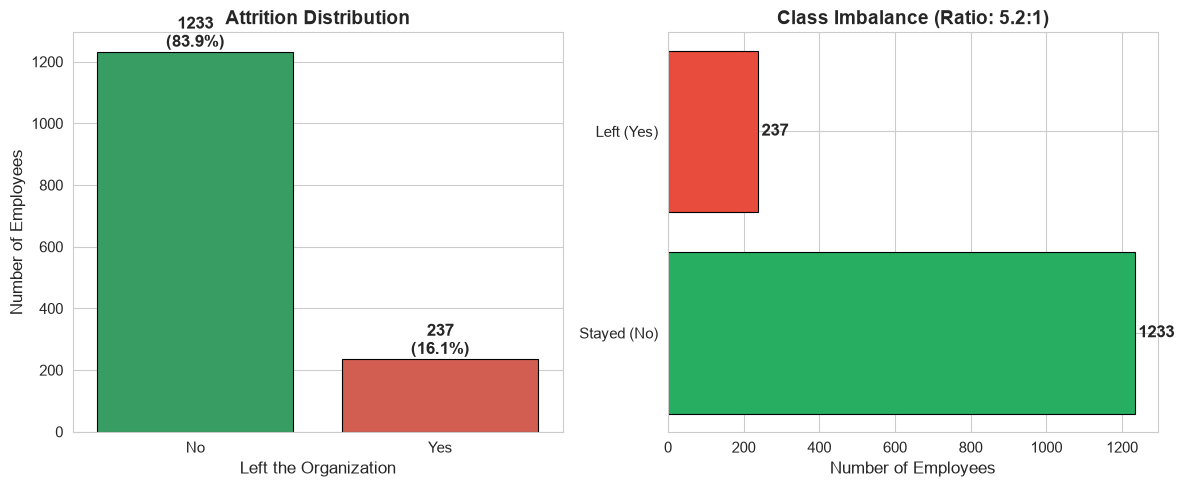

Attrition Rate: 16.1%
Class Imbalance Ratio: 5.2:1 (No:Yes)

Modeling consideration: Will need stratified sampling, class weights, or SMOTE.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Detailed count plot
colors_attr = ['#27ae60', '#e74c3c']
sns.countplot(data=df, x='Attrition', ax=axes[0], palette=colors_attr,
              edgecolor='black', linewidth=0.8, order=['No', 'Yes'])
axes[0].set_title('Attrition Distribution', fontweight='bold')
axes[0].set_xlabel('Left the Organization')
axes[0].set_ylabel('Number of Employees')

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}\n({p.get_height()/len(df)*100:.1f}%)',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Imbalance visualization
attrition_counts = df['Attrition'].value_counts()
ratio = attrition_counts['No'] / attrition_counts['Yes']

axes[1].barh(['Stayed (No)', 'Left (Yes)'],
             [attrition_counts['No'], attrition_counts['Yes']],
             color=colors_attr, edgecolor='black', linewidth=0.8)
axes[1].set_title(f'Class Imbalance (Ratio: {ratio:.1f}:1)', fontweight='bold')
axes[1].set_xlabel('Number of Employees')

for i, v in enumerate([attrition_counts['No'], attrition_counts['Yes']]):
    axes[1].text(v + 10, i, f'{v}', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/03_attrition_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Attrition Rate: {attrition_counts["Yes"] / len(df) * 100:.1f}%')
print(f'Class Imbalance Ratio: {ratio:.1f}:1 (No:Yes)')
print(f'\nModeling consideration: Will need stratified sampling, class weights, or SMOTE.')

**Interpretation:** The target variable confirms a significant class imbalance with approximately 16% attrition rate. The majority class (No Attrition) outnumbers the minority class by approximately 5:1.

**Business Implication:** While 16% attrition may seem moderate, it represents real organizational cost. At scale, even a 1% reduction in attrition can save significant recruitment and training expenses. The imbalance also means predictive models must be carefully calibrated to avoid simply predicting "No" for all cases.

---
## 12. Key Findings

1. **Age**: Near-normal distribution centered around 36-37 years. The workforce is mature with limited representation at career extremes.

2. **Monthly Income**: Strongly right-skewed, typical of salary distributions. Large gap between mean and median indicates income inequality within the organization.

3. **Weekly Hours**: A significant portion of employees work beyond standard 40-hour weeks, suggesting widespread overwork culture.

4. **OverTime**: Nearly a third of employees work overtime, creating a substantial at-risk population for burnout.

5. **Job Satisfaction**: Roughly uniform distribution across levels. No dominant satisfaction level, but ~40% report low-to-medium satisfaction.

6. **Work-Life Balance**: Concentrated at level 3, with a notable minority at the lowest level who are at high burnout risk.

7. **Workload Score**: Distribution reveals the perceived workload burden. High-workload employees form a critical risk segment.

8. **Total Working Years**: Right-skewed, indicating many early-career employees who may have different retention needs.

9. **Attrition**: 16.1% rate with 5:1 class imbalance requiring careful modeling approaches.

---
## 13. Business Implications

1. **Burnout risk segments**: Employees with high workload scores, overtime, and poor work-life balance form overlapping risk groups. Identifying individuals in multiple risk categories should be a priority.

2. **Compensation strategy**: The skewed income distribution suggests that lower-paid employees (the majority) may be particularly sensitive to compensation-related attrition.

3. **Early intervention timing**: With many early-career employees in the workforce, onboarding and early-tenure engagement programs could have significant impact.

4. **Workload management**: The widespread overtime and high workload scores suggest a systemic issue rather than isolated cases, requiring organizational-level intervention.

---
*Next: Proceed to `04_bivariate_eda.ipynb` for relationship analysis between features and attrition.*